# Geração das figuras do TCC

**Trabalho:** *Uso de LLMs com Retrieval-Augmented Generation para democratização do acesso à informação em editais de concursos públicos de Ciência de Dados*

**Autores:** Leonardo Fernandes de Castro · Júlio Patti Pereira · João Vítor Dallegrave

---

Este notebook produz **exatamente** as 9 figuras utilizadas no TCC:

1. `fig_arquitetura.png` — Figura 1, arquitetura geral da ferramenta
2. `fig_pipeline.png` — Figura 2, pipeline de ingestão dos editais
3. `fig_acuracia_factual.png` — Gráfico 1, acurácia factual média por sistema
4. `fig_concisao.png` — Gráfico 2, concisão média por sistema
5. `fig_custo.png` — Gráfico 3, custo médio por pergunta (API)
6. `fig_latencia.png` — Gráfico 4, latência mediana (API)
7. `fig_custo_x_acuracia.png` — Gráfico 5, custo × acurácia
8. `fig_latencia_x_acuracia.png` — Gráfico 6, latência × acurácia
9. `fig_concisao_x_tokens.png` — Gráfico 7, concisão × tokens médios

## Pré-requisitos

Antes de executar, garanta a seguinte estrutura ao lado deste notebook:

```
├── gerar_figuras.ipynb       (este arquivo)
├── utils.py                  (helpers compartilhados)
├── data/
│   └── result_unificado_final.xlsx
└── figs/                     (criada automaticamente)
```

**Dependências Python:** `pandas`, `numpy`, `matplotlib`, `scipy`, `openpyxl`.

Instale, se necessário, com:

```bash
pip install pandas numpy matplotlib scipy openpyxl
```

## 1. Setup: imports, estilo e carga de dados

A célula abaixo importa as bibliotecas, aplica o estilo padrão do estudo (`utils.estilo_padrao()`) e carrega a base consolidada de 1.650 respostas (11 sistemas × 150 perguntas).

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd
from scipy import stats

from utils import (
    carregar_dados, agrega_por_modelo, estilo_padrao,
    ORDEM_MODELOS, CORES_PROVEDOR, PROVEDOR, MODELO_DISPLAY,
    MARKER_API, MARKER_CHAT,
    legenda_provedor_origem, titulo_acima, anota_sem_sobrepor,
)

os.makedirs('figs', exist_ok=True)
estilo_padrao()

df = carregar_dados()
mestre = agrega_por_modelo(df)

print(f'Linhas na base: {len(df)}')
print(f'Sistemas avaliados: {mestre.shape[0]}')
mestre[['precisao', 'concisao', 'custo_usd', 'latencia_s', 'tokens_resp', 'origem']]

Linhas na base: 1650
Sistemas avaliados: 11


,precisao,concisao,custo_usd,latencia_s,tokens_resp,origem
modelo_display,,,,,,
GPT-4o mini,0.910000,0.886667,0.001448,5.631733,140.720000,API
GPT-5.4 mini,0.906667,0.993333,0.006027,2.946267,100.133333,API
GPT-5.4,0.963333,0.973333,0.023597,5.689867,107.413333,API
GPT-5.5,0.996667,0.973333,0.054732,21.328200,117.206667,API
Claude Haiku 4.5,0.936667,0.533333,0.017230,17.502000,231.860000,API
Claude Sonnet 4.6,0.973333,0.360000,0.053790,12.916733,321.400000,API
Claude Opus 4.7,0.976667,0.486667,0.106961,12.311400,271.706667,API
DeepSeek v4 Flash,0.970000,0.560000,0.001981,8.561600,264.573333,API
DeepSeek v4 Pro,0.963333,0.473333,0.025010,17.885267,296.453333,API


## 2. Figura 1 — Arquitetura geral da ferramenta

Diagrama em duas linhas montado manualmente com `FancyBboxPatch` e `FancyArrowPatch`. 
Caixas coloridas representam etapas (entrada · estruturação · indexação · consulta · interface), 
e as setas indicam o fluxo do PDF do edital até a resposta ao usuário.

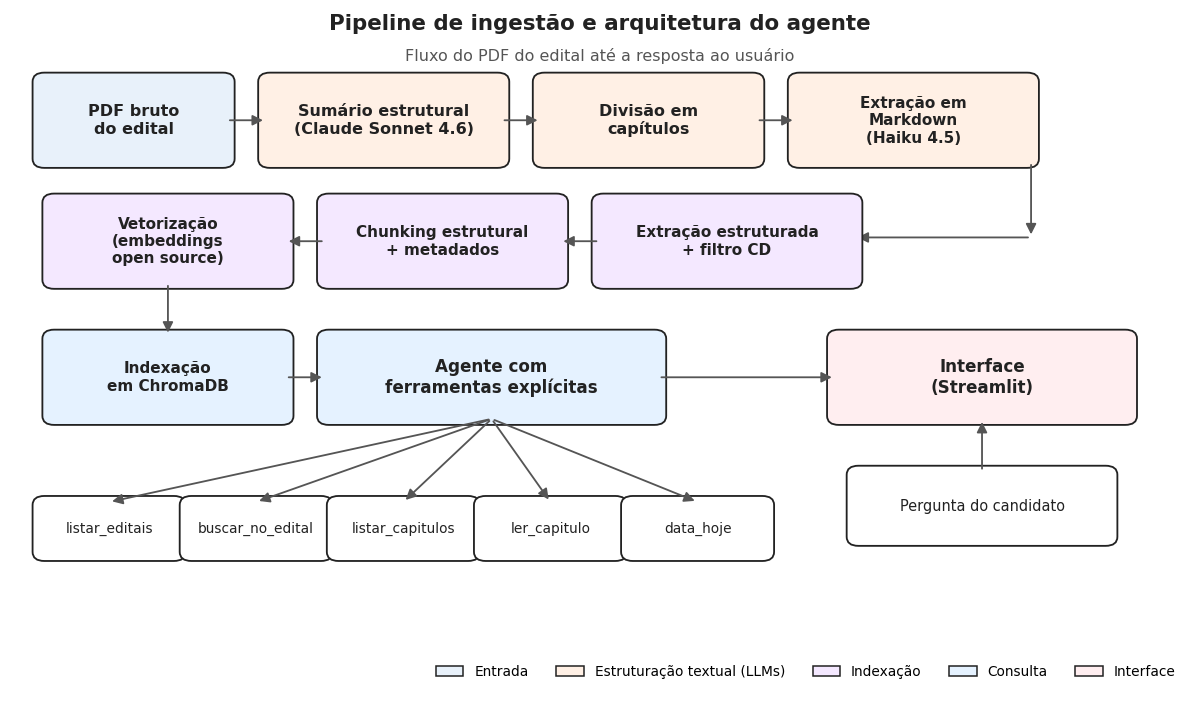

In [2]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 9)
ax.axis('off')

arrow_color = '#555555'

def add_box(x, y, w, h, label, fill='#F4F4F4', bold=True, fontsize=10.5, edgecolor='#222'):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.08,rounding_size=0.12",
                         linewidth=1.2, edgecolor=edgecolor, facecolor=fill)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight=weight, color='#222', wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='-|>', mutation_scale=14,
                            linewidth=1.2, color=arrow_color)
    ax.add_patch(arrow)

# Linha 1 — Ingestão (PDF → estruturação textual)
add_box(0.3, 7.0, 1.9, 1.1, 'PDF bruto\ndo edital', fill='#E8F1FA')
add_box(2.6, 7.0, 2.4, 1.1, 'Sumário estrutural\n(Claude Sonnet 4.6)', fill='#FFF0E5')
add_box(5.4, 7.0, 2.2, 1.1, 'Divisão em\ncapítulos', fill='#FFF0E5')
add_box(8.0, 7.0, 2.4, 1.1, 'Extração em\nMarkdown\n(Haiku 4.5)', fill='#FFF0E5', fontsize=10)

add_arrow(2.2, 7.55, 2.6, 7.55)
add_arrow(5.0, 7.55, 5.4, 7.55)
add_arrow(7.6, 7.55, 8.0, 7.55)
add_arrow(10.4, 7.0, 10.4, 6.0)
add_arrow(10.4, 6.0, 8.6, 6.0)

# Linha 2 — Indexação
add_box(6.0, 5.4, 2.6, 1.1, 'Extração estruturada\n+ filtro CD', fill='#F4E8FF', fontsize=10)
add_box(3.2, 5.4, 2.4, 1.1, 'Chunking estrutural\n+ metadados', fill='#F4E8FF', fontsize=10)
add_box(0.4, 5.4, 2.4, 1.1, 'Vetorização\n(embeddings\nopen source)', fill='#F4E8FF', fontsize=10)
add_arrow(6.0, 5.95, 5.6, 5.95)
add_arrow(3.2, 5.95, 2.8, 5.95)

# Linha 3 — Consulta + Interface
add_box(0.4, 3.6, 2.4, 1.1, 'Indexação\nem ChromaDB', fill='#E5F2FF', fontsize=10)
add_arrow(1.6, 5.4, 1.6, 4.7)

add_box(3.2, 3.6, 3.4, 1.1, 'Agente com\nferramentas explícitas', fill='#E5F2FF', fontsize=11)
add_arrow(2.8, 4.15, 3.2, 4.15)

tools = [
    ('listar_editais', 0.3),
    ('buscar_no_edital', 1.8),
    ('listar_capitulos', 3.3),
    ('ler_capitulo', 4.8),
    ('data_hoje', 6.3),
]
for name, x in tools:
    add_box(x, 1.8, 1.4, 0.7, name, fill='#FFFFFF', bold=False, fontsize=9)
    add_arrow(4.9, 3.6, x + 0.7, 2.5)

add_box(8.4, 3.6, 3.0, 1.1, 'Interface\n(Streamlit)', fill='#FFEEF0', fontsize=11)
add_arrow(6.6, 4.15, 8.4, 4.15)

add_box(8.6, 2.0, 2.6, 0.9, 'Pergunta do candidato', fill='#FFFFFF', bold=False, fontsize=9.5)
add_arrow(9.9, 2.9, 9.9, 3.6)

# Título e legenda
ax.text(6, 8.7, 'Pipeline de ingestão e arquitetura do agente',
        ha='center', va='bottom', fontsize=14, fontweight='bold', color='#222')
ax.text(6, 8.3, 'Fluxo do PDF do edital até a resposta ao usuário',
        ha='center', va='bottom', fontsize=10.5, color='#555')

legend_patches = [
    mpatches.Patch(facecolor='#E8F1FA', edgecolor='#222', label='Entrada'),
    mpatches.Patch(facecolor='#FFF0E5', edgecolor='#222', label='Estruturação textual (LLMs)'),
    mpatches.Patch(facecolor='#F4E8FF', edgecolor='#222', label='Indexação'),
    mpatches.Patch(facecolor='#E5F2FF', edgecolor='#222', label='Consulta'),
    mpatches.Patch(facecolor='#FFEEF0', edgecolor='#222', label='Interface'),
]
ax.legend(handles=legend_patches, loc='lower right',
          ncol=5, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_arquitetura.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Figura 2 — Pipeline de ingestão dos editais

Versão simplificada e linear das oito etapas do pipeline: do PDF bruto até a base vetorial pronta para consulta. Cores agrupam etapas afins (entrada · estruturação por LLMs · preparação para RAG · indexação).

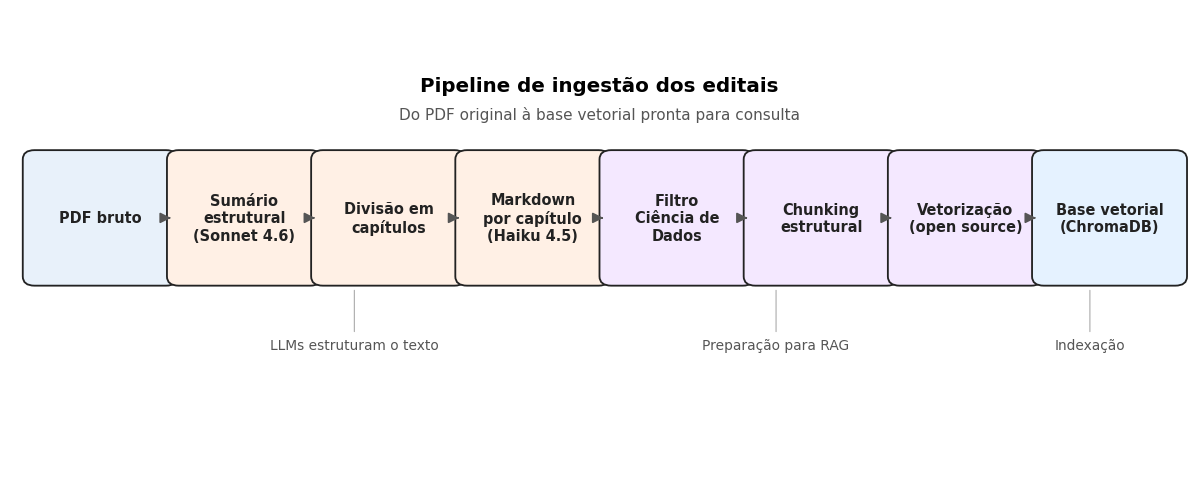

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

def add_box(x, y, w, h, label, fill='#F4F4F4', bold=True, fontsize=10.5, edgecolor='#222'):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.08,rounding_size=0.12",
                         linewidth=1.2, edgecolor=edgecolor, facecolor=fill)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight=weight, color='#222', wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='-|>', mutation_scale=14,
                            linewidth=1.2, color='#555555')
    ax.add_patch(arrow)

stages = [
    ('PDF bruto', '#E8F1FA'),
    ('Sumário\nestrutural\n(Sonnet 4.6)', '#FFF0E5'),
    ('Divisão em\ncapítulos', '#FFF0E5'),
    ('Markdown\npor capítulo\n(Haiku 4.5)', '#FFF0E5'),
    ('Filtro\nCiência de\nDados', '#F4E8FF'),
    ('Chunking\nestrutural', '#F4E8FF'),
    ('Vetorização\n(open source)', '#F4E8FF'),
    ('Base vetorial\n(ChromaDB)', '#E5F2FF'),
]
x_start = 0.2
w = 1.42
gap = 0.05

for i, (label, color) in enumerate(stages):
    x = x_start + i * (w + gap)
    add_box(x, 2.5, w, 1.6, label, fill=color, fontsize=9.5)
    if i > 0:
        add_arrow(x - gap - 0.04, 3.3, x - 0.04, 3.3)

ax.text(6, 4.9, 'Pipeline de ingestão dos editais',
        ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.text(6, 4.55, 'Do PDF original à base vetorial pronta para consulta',
        ha='center', va='bottom', fontsize=10, color='#555')

ax.annotate('LLMs estruturam o texto', xy=(3.5, 2.4), xytext=(3.5, 1.6),
            ha='center', fontsize=9, color='#555',
            arrowprops=dict(arrowstyle='-', color='#999', lw=0.6))
ax.annotate('Preparação para RAG', xy=(7.8, 2.4), xytext=(7.8, 1.6),
            ha='center', fontsize=9, color='#555',
            arrowprops=dict(arrowstyle='-', color='#999', lw=0.6))
ax.annotate('Indexação', xy=(11.0, 2.4), xytext=(11.0, 1.6),
            ha='center', fontsize=9, color='#555',
            arrowprops=dict(arrowstyle='-', color='#999', lw=0.6))

plt.tight_layout()
plt.savefig('figs/fig_pipeline.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Gráfico 1 — Acurácia factual média por sistema

Barras horizontais ordenadas crescentemente pela média final (0 / 0,5 / 1) após adjudicação humana das 121 divergências entre os juízes automáticos. 
Cor identifica o provedor; hachura `///` indica os chats web (não-API).

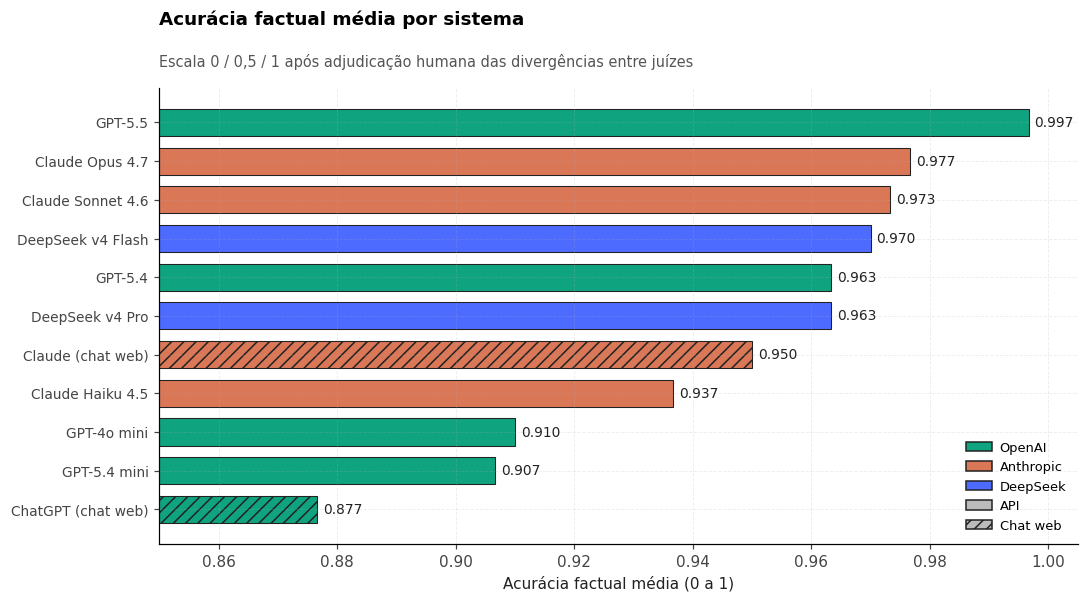

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.6))
m_sorted = mestre.sort_values('precisao', ascending=True)
xs = np.arange(len(m_sorted))
cores = m_sorted['cor'].tolist()
hatch = ['///' if o == 'Chat web' else None for o in m_sorted['origem']]

bars = ax.barh(xs, m_sorted['precisao'].values, color=cores,
               edgecolor='#222', linewidth=0.7, height=0.7)
for b, h in zip(bars, hatch):
    if h:
        b.set_hatch(h)
ax.set_yticks(xs)
ax.set_yticklabels(m_sorted.index, fontsize=9)
ax.set_xlim(0.85, 1.005)
ax.set_xlabel('Acurácia factual média (0 a 1)')

for x, v in zip(xs, m_sorted['precisao'].values):
    ax.text(v + 0.001, x, f'{v:.3f}', ha='left', va='center', fontsize=9, color='#222')

titulo_acima(ax, 'Acurácia factual média por sistema',
             'Escala 0 / 0,5 / 1 após adjudicação humana das divergências entre juízes')

# Legenda custom: 3 cores de provedores + estilo sólido (API) vs hachurado (chat web).
# Em barras, "API vs Chat web" é diferenciado pela hachura — círculo/quadrado não se aplica.
from matplotlib.patches import Patch
legenda_handles = [
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
    Patch(facecolor='#bbb', edgecolor='#222', label='API'),
    Patch(facecolor='#bbb', edgecolor='#222', hatch='///', label='Chat web'),
]
ax.legend(handles=legenda_handles, loc='lower right', fontsize=8.5,
          handletextpad=0.6, labelspacing=0.5, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_acuracia_factual.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Gráfico 2 — Concisão média por sistema

Concisão em escala binária (1 = concisa, 0 = verbosa), julgada por GPT-5.5 como juiz único e em comparação por lote (todas as 11 respostas de uma mesma pergunta avaliadas juntas).

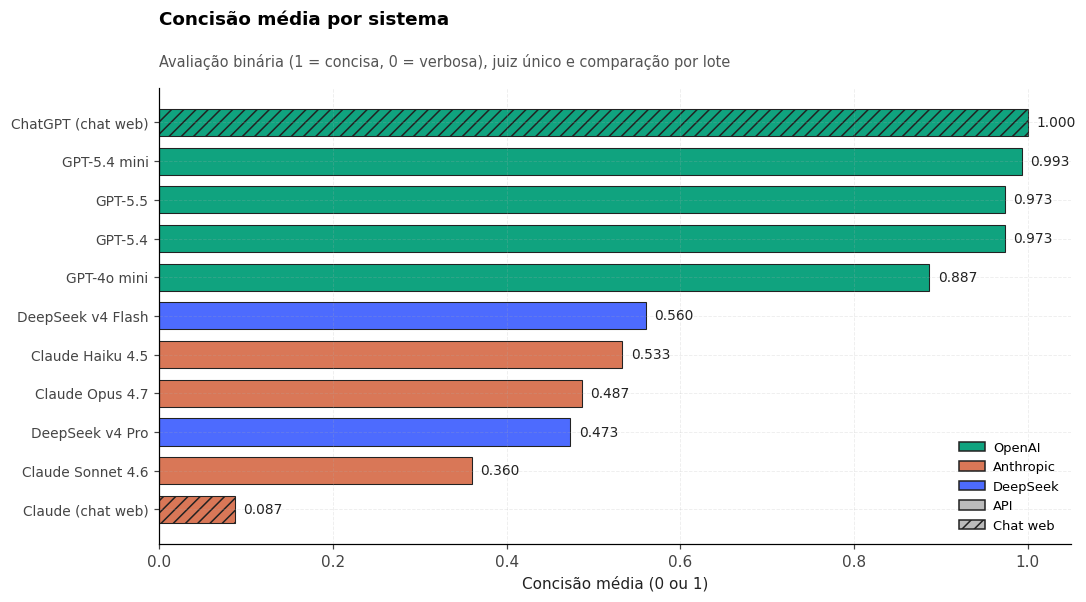

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.6))
m_sorted = mestre.sort_values('concisao', ascending=True)
xs = np.arange(len(m_sorted))
cores = m_sorted['cor'].tolist()
hatch = ['///' if o == 'Chat web' else None for o in m_sorted['origem']]

bars = ax.barh(xs, m_sorted['concisao'].values, color=cores,
               edgecolor='#222', linewidth=0.7, height=0.7)
for b, h in zip(bars, hatch):
    if h:
        b.set_hatch(h)
ax.set_yticks(xs)
ax.set_yticklabels(m_sorted.index, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Concisão média (0 ou 1)')

for x, v in zip(xs, m_sorted['concisao'].values):
    ax.text(v + 0.01, x, f'{v:.3f}', ha='left', va='center', fontsize=9, color='#222')

titulo_acima(ax, 'Concisão média por sistema',
             'Avaliação binária (1 = concisa, 0 = verbosa), juiz único e comparação por lote')

from matplotlib.patches import Patch
legenda_handles = [
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
    Patch(facecolor='#bbb', edgecolor='#222', label='API'),
    Patch(facecolor='#bbb', edgecolor='#222', hatch='///', label='Chat web'),
]
ax.legend(handles=legenda_handles, loc='lower right', fontsize=8.5,
          handletextpad=0.6, labelspacing=0.5, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_concisao.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Gráfico 3 — Custo médio por pergunta (modelos via API)

Custo médio em USD por pergunta. Os dois chats web ficam de fora desta dimensão porque não há mensuração padronizada de custo por requisição. 
Eixo horizontal em escala **logarítmica** — a amplitude é grande (US$ 0,0014 a US$ 0,1070, ou seja, ~74×).

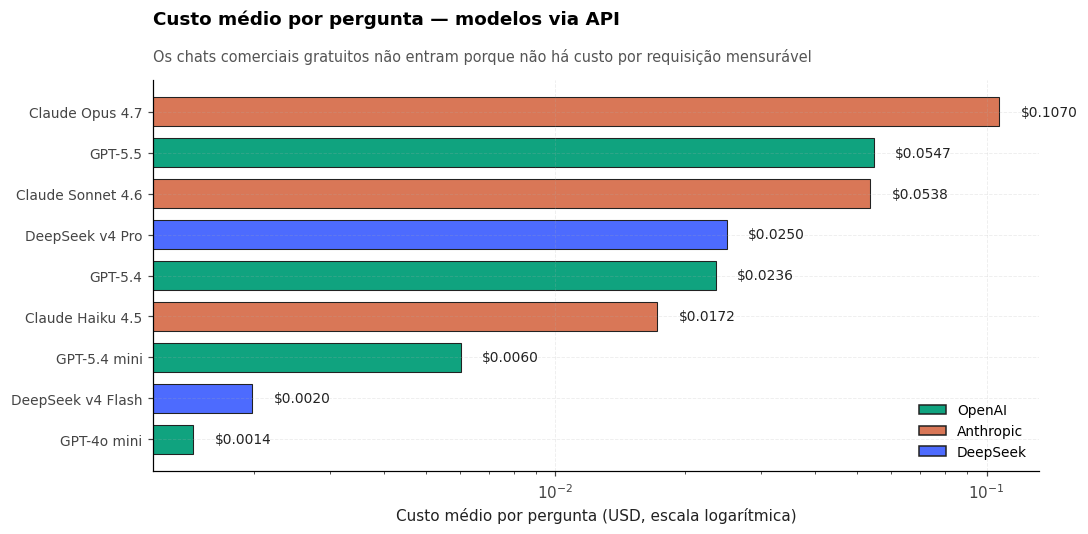

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.0))
api = mestre[mestre['origem'] == 'API'].sort_values('custo_usd', ascending=True)
xs = np.arange(len(api))
cores = api['cor'].tolist()

bars = ax.barh(xs, api['custo_usd'].values, color=cores,
               edgecolor='#222', linewidth=0.7, height=0.7)
ax.set_yticks(xs)
ax.set_yticklabels(api.index, fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Custo médio por pergunta (USD, escala logarítmica)')
for x, v in zip(xs, api['custo_usd'].values):
    ax.text(v * 1.12, x, f'${v:.4f}', ha='left', va='center', fontsize=9, color='#222')

titulo_acima(ax, 'Custo médio por pergunta — modelos via API',
             'Os chats comerciais gratuitos não entram porque não há custo por requisição mensurável')

# Legenda: só provedores (todos os 11 sistemas via API são desses 3 provedores).
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
], loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_custo.png', dpi=160, bbox_inches='tight')
plt.show()


## 7. Gráfico 4 — Latência media de resposta (modelos via API)
Chats web não foram cronometrados de forma padronizada.

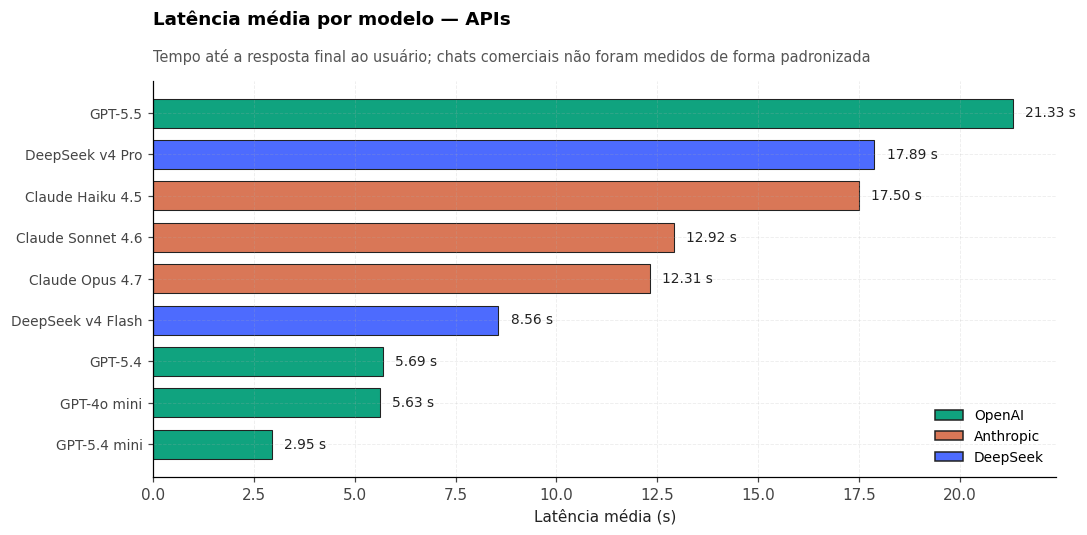

In [21]:
fig, ax = plt.subplots(figsize=(10, 5.0))
api_lat = df[df['origem'] == 'API'].groupby('modelo_display')['latencia_s'].mean()

# Mapear cada modelo de display -> provedor -> cor
provedor_por_display = {disp: PROVEDOR[k] for k, disp in MODELO_DISPLAY.items()}
api_df_sorted = api_lat.sort_values(ascending=True).to_frame('latencia_média')
api_df_sorted['cor'] = api_df_sorted.index.map(lambda m: CORES_PROVEDOR[provedor_por_display[m]])

xs = np.arange(len(api_df_sorted))
bars = ax.barh(xs, api_df_sorted['latencia_média'].values,
               color=api_df_sorted['cor'].tolist(),
               edgecolor='#222', linewidth=0.7, height=0.7)
ax.set_yticks(xs)
ax.set_yticklabels(api_df_sorted.index, fontsize=9)
ax.set_xlabel('Latência média (s)')
for x, v in zip(xs, api_df_sorted['latencia_média'].values):
    ax.text(v + 0.3, x, f'{v:.2f} s', ha='left', va='center', fontsize=9, color='#222')

titulo_acima(ax, 'Latência média por modelo — APIs',
             'Tempo até a resposta final ao usuário; chats comerciais não foram medidos de forma padronizada')

# Legenda: só provedores.
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
], loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_latencia.png', dpi=160, bbox_inches='tight')
plt.show()


## 8. Gráfico 5 — Custo × acurácia factual

Dispersão dos 9 modelos via API combinando custo (eixo X, log) e acurácia (eixo Y). Permite ler visualmente a **fronteira de Pareto**: DeepSeek v4 Flash, GPT-5.4 e GPT-5.5 dominam a faixa de melhor custo-benefício.

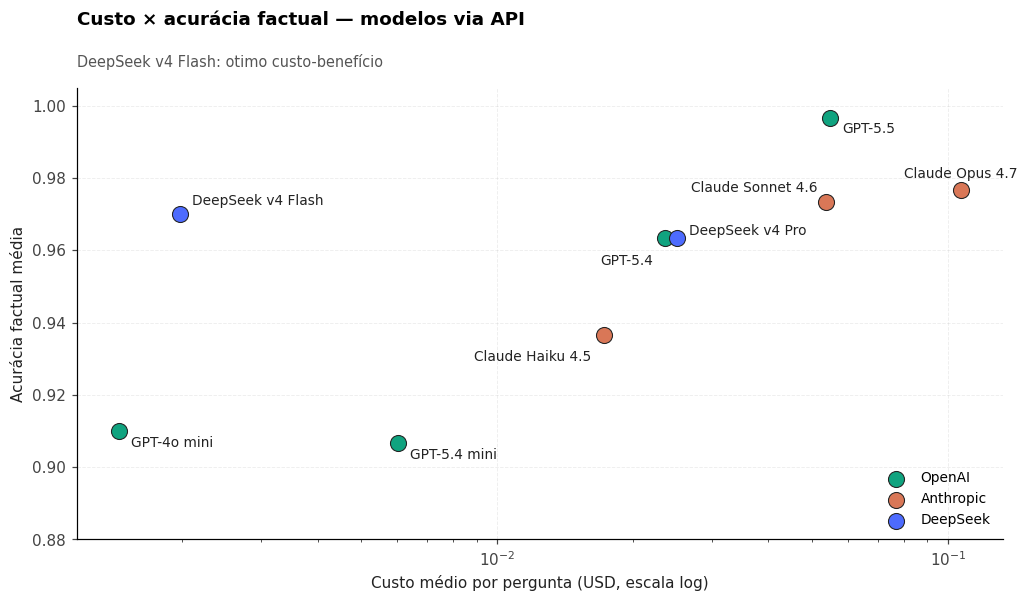

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
api_m = mestre[mestre['origem'] == 'API'].dropna(subset=['custo_usd'])

for prov in api_m['provedor'].unique():
    sub = api_m[api_m['provedor'] == prov]
    ax.scatter(sub['custo_usd'], sub['precisao'], s=110,
               c=CORES_PROVEDOR[prov], marker=MARKER_API, edgecolor='#222',
               linewidth=0.7, label=prov, zorder=3)

ax.set_xscale('log')
ax.set_xlabel('Custo médio por pergunta (USD, escala log)')
ax.set_ylabel('Acurácia factual média')
ax.set_ylim(0.88, 1.005)

labels = api_m.index.tolist()
xs = api_m['custo_usd'].values
ys = api_m['precisao'].values
offsets = {
    'GPT-5.5': (8, -3),
    'Claude Opus 4.7': (0, 6),
    'Claude Sonnet 4.6': (-6, 5),
    'DeepSeek v4 Flash': (8, 4),
    'DeepSeek v4 Pro': (8, 0),
    'GPT-5.4': (-8, -10),
    'Claude Haiku 4.5': (-8, -10),
    'GPT-4o mini': (8, -3),
    'GPT-5.4 mini': (8, -3),
}
anota_sem_sobrepor(ax, xs, ys, labels, fontsize=9, offsets_manuais=offsets)

titulo_acima(ax, 'Custo × acurácia factual — modelos via API',
             'DeepSeek v4 Flash: otimo custo-benefício')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('figs/fig_custo_x_acuracia.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Gráfico 6 — Latência × acurácia factual

Análogo ao Gráfico 5, mas com latência média (s) no eixo X. GPT-5.4 e GPT-5.4 mini concentram-se na zona de baixa latência; GPT-5.5 paga o preço da espera para liderar acurácia.

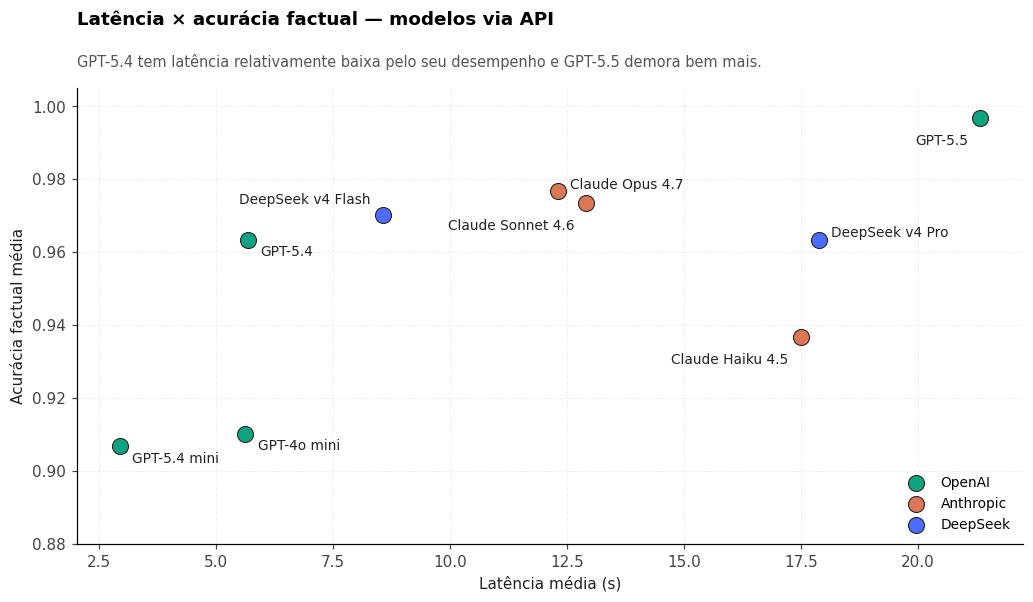

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
api_m = mestre[mestre['origem'] == 'API'].dropna(subset=['latencia_s'])

for prov in api_m['provedor'].unique():
    sub = api_m[api_m['provedor'] == prov]
    ax.scatter(sub['latencia_s'], sub['precisao'], s=110,
               c=CORES_PROVEDOR[prov], marker=MARKER_API, edgecolor='#222',
               linewidth=0.7, label=prov, zorder=3)

ax.set_xlabel('Latência média (s)')
ax.set_ylabel('Acurácia factual média')
ax.set_ylim(0.88, 1.005)

labels = api_m.index.tolist()
xs = api_m['latencia_s'].values
ys = api_m['precisao'].values
offsets = {
    'GPT-5.5': (-8, -10),
    'Claude Opus 4.7': (8, 0),
    'Claude Sonnet 4.6': (-8, -10),
    'DeepSeek v4 Flash': (-8, 6),
    'DeepSeek v4 Pro': (8, 0),
    'GPT-5.4': (8, -3),
    'Claude Haiku 4.5': (-8, -10),
    'GPT-4o mini': (8, -3),
    'GPT-5.4 mini': (8, -3),
}
anota_sem_sobrepor(ax, xs, ys, labels, fontsize=9, offsets_manuais=offsets)

titulo_acima(ax, 'Latência × acurácia factual — modelos via API',
             'GPT-5.4 tem latência relativamente baixa pelo seu desempenho e GPT-5.5 demora bem mais.')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('figs/fig_latencia_x_acuracia.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Gráfico 7 — Concisão correlacionada com tokens de saída

Dispersão dos **11 sistemas** (incluindo chats web — marcador quadrado) cruzando tokens médios na resposta (eixo X) e concisão média (eixo Y). Calcula no fim o **ρ de Spearman**, esperado em torno de −0,989, que sustenta o achado de que respostas mais longas tendem a ser menos concisas.

Spearman ρ = -0.9886, p = 1.03e-08


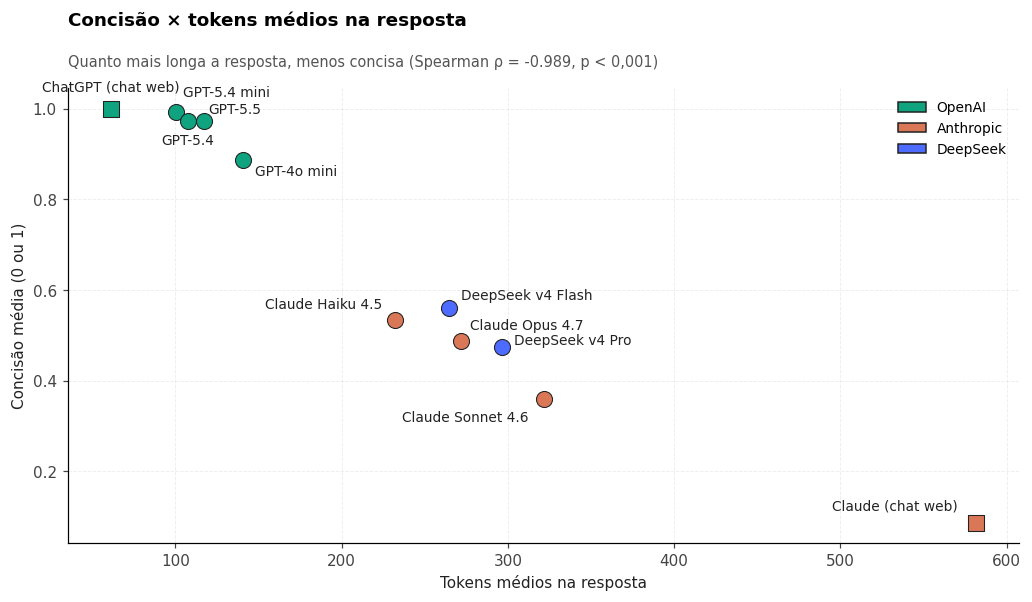

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
sub_m = mestre.dropna(subset=['concisao', 'tokens_resp'])

for prov in sub_m['provedor'].unique():
    sub = sub_m[sub_m['provedor'] == prov]
    for o, marker in [('API', MARKER_API), ('Chat web', MARKER_CHAT)]:
        sub2 = sub[sub['origem'] == o]
        if len(sub2) == 0:
            continue
        ax.scatter(sub2['tokens_resp'], sub2['concisao'], s=110,
                   c=CORES_PROVEDOR[prov], marker=marker, edgecolor='#222',
                   linewidth=0.7, zorder=3)

ax.set_xlabel('Tokens médios na resposta')
ax.set_ylabel('Concisão média (0 ou 1)')

labels = sub_m.index.tolist()
xs = sub_m['tokens_resp'].values
ys = sub_m['concisao'].values
offsets = {
    'GPT-5.5': (3, 3),
    'Claude Opus 4.7': (6, 6),
    'Claude Sonnet 4.6': (-10, -8),
    'DeepSeek v4 Flash': (8, 4),
    'DeepSeek v4 Pro': (8, 0),
    'GPT-5.4': (0, -8),
    'Claude Haiku 4.5': (-8, 6),
    'GPT-4o mini': (8, -3),
    'GPT-5.4 mini': (5, 8),
    'ChatGPT (chat web)': (0, 10),
    'Claude (chat web)': (-12, 6),
}
anota_sem_sobrepor(ax, xs, ys, labels, fontsize=9, offsets_manuais=offsets)

rho, p = stats.spearmanr(xs, ys)
print(f'Spearman ρ = {rho:.4f}, p = {p:.3g}')

titulo_acima(ax, 'Concisão × tokens médios na resposta',
             f'Quanto mais longa a resposta, menos concisa (Spearman ρ = {rho:.3f}, p < 0,001)')
legenda_provedor_origem(ax, loc='upper right')

# Legenda: só provedores (todos os 11 sistemas via API são desses 3 provedores).
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
], loc='upper right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figs/fig_concisao_x_tokens.png', dpi=160, bbox_inches='tight')
plt.show()

## 11. Verificação final

Lista os PNGs efetivamente salvos em `figs/`. Devem ser os 9 arquivos usados no TCC.

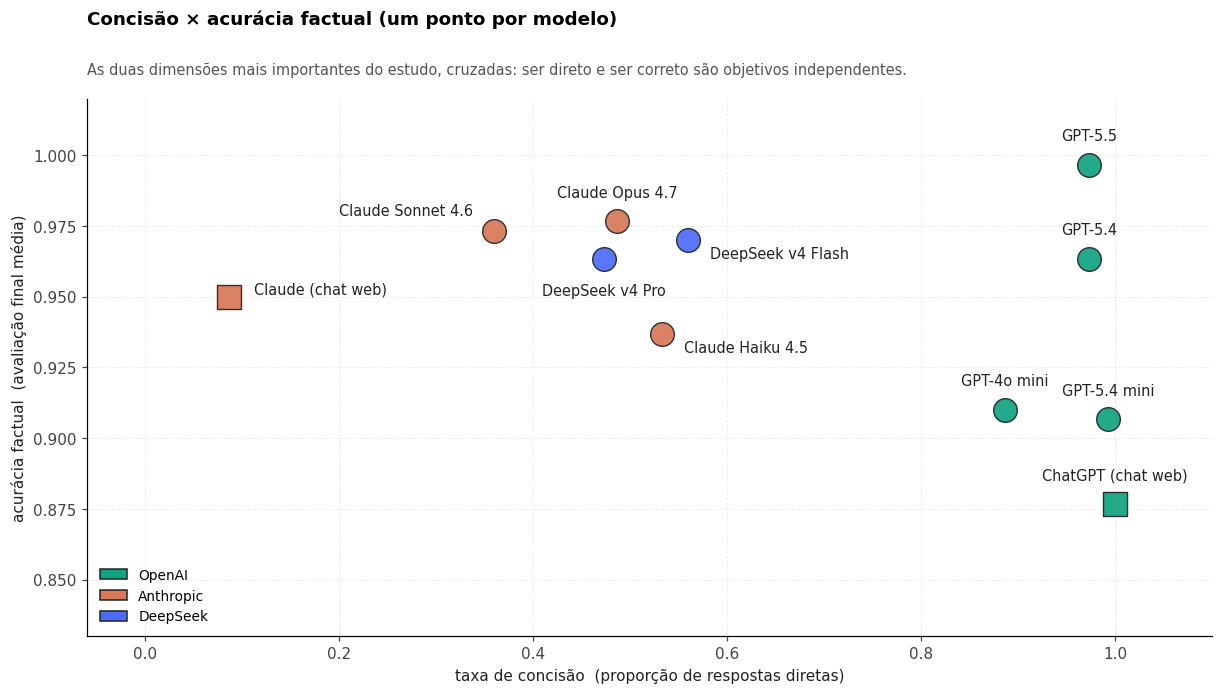

In [40]:
## 1b. Concisão × acurácia factual — as duas dimensões juntas

x = mestre['concisao']
y = mestre['precisao']

r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')

# Cada modelo com sua cor (provedor) e marcador (canal)
for nome, row in mestre.iterrows():
    ax.scatter(row['concisao'], row['precisao'],
               s=240, color=row['cor'], marker=row['marker'],
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

# Linha de tendência (só para guiar o olho)
# sl, ic_, *_ = stats.linregress(x, y)
# xx = np.linspace(-0.02, 1.02, 100)
# ax.plot(xx, sl * xx + ic_, color='#888', lw=0.9, ls='--', zorder=1,
#         label='tendência linear')

# Rótulos (editáveis — mova o offset do modelo que estiver disputando espaço)
anota_sem_sobrepor(ax, x.values, y.values, mestre.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 0,  14),
        'GPT-5.4 mini':       ( 0,  14),
        'GPT-5.4':            ( 0,  14),
        'GPT-5.5':            ( 0,  14),
        'ChatGPT (chat web)': ( 0,  14),   # concisão = 1,0, encostado na borda direita
        'Claude Haiku 4.5':   ( 14,  -4),
        'Claude Sonnet 4.6':  ( -14,   8),
        'Claude Opus 4.7':    ( 0,  14),
        'Claude (chat web)':  ( 16,   0),   # concisão ~0,09, perto da borda esquerda
        'DeepSeek v4 Flash':  ( 14,  -4),
        'DeepSeek v4 Pro':    (  0, -16),
    })

ax.set_xlim(-0.06, 1.10)
ax.set_ylim(0.83, 1.02)
ax.set_xlabel('taxa de concisão  (proporção de respostas diretas)')
ax.set_ylabel('acurácia factual  (avaliação final média)')

# # Patamar de referência de 95%, como no notebook 02
# ax.axhline(0.95, ls=':', color='#888', lw=0.8, zorder=1)
# ax.text(-0.04, 0.951, '95%', fontsize=8.5, color='#777', va='bottom', ha='left')

# ax.text(0.98, 0.05,
#         f'Pearson r = {r_p:.3f}   (p = {p_p:.1e})\n'
#         f'Spearman ρ = {r_s:.3f}   (p = {p_s:.1e})',
#         transform=ax.transAxes, va='bottom', ha='right',
#         fontsize=10,
#         bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#ccc'))

legenda_provedor_origem(ax, loc='lower left')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],    edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'],  edgecolor='#222', label='DeepSeek'),
], loc='lower left', fontsize=9, frameon=False)

titulo_acima(ax,
    'Concisão × acurácia factual (um ponto por modelo)',
    'As duas dimensões mais importantes do estudo, cruzadas: ser direto e ser correto são objetivos independentes.')

plt.show()

In [24]:
for f in sorted(os.listdir('figs')):
    if f.endswith('.png'):
        sz = os.path.getsize(f'figs/{f}')
        print(f'  {f:35s} {sz/1024:6.1f} KB')

  fig_acuracia_factual.png             130.0 KB
  fig_arquitetura.png                  164.8 KB
  fig_concisao.png                     125.5 KB
  fig_concisao_x_tokens.png            108.0 KB
  fig_custo.png                        105.4 KB
  fig_custo_x_acuracia.png              99.2 KB
  fig_latencia.png                     106.3 KB
  fig_latencia_x_acuracia.png          109.4 KB
  fig_pipeline.png                      83.3 KB
